In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df = pd.read_csv("Dataset.csv")
df.head()

,order_id,region,category,sales_amount,profit,month
0,1,South,Furniture,604,1396,Aug
1,2,East,Office Supplies,4813,136,May
2,3,West,Furniture,4771,849,Apr
3,4,West,Office Supplies,2200,603,Aug
4,5,East,Furniture,2956,1080,Jun


In [29]:
print(df.columns)

Index(['order_id', 'region', 'category', 'sales_amount', 'profit', 'month'], dtype='str')


In [30]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      100 non-null    int64
 1   region        100 non-null    str  
 2   category      100 non-null    str  
 3   sales_amount  100 non-null    int64
 4   profit        100 non-null    int64
 5   month         100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


order_id        0
region          0
category        0
sales_amount    0
profit          0
month           0
dtype: int64

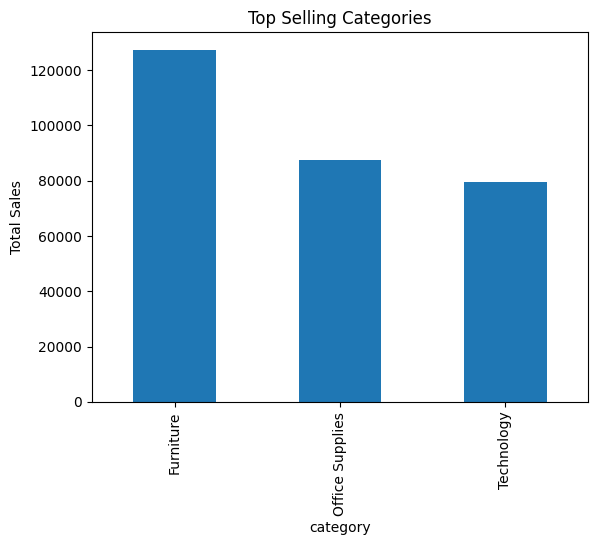

In [31]:
top_categories = (
    df.groupby("category")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

top_categories.plot(kind="bar", title="Top Selling Categories")
plt.ylabel("Total Sales")
plt.show()

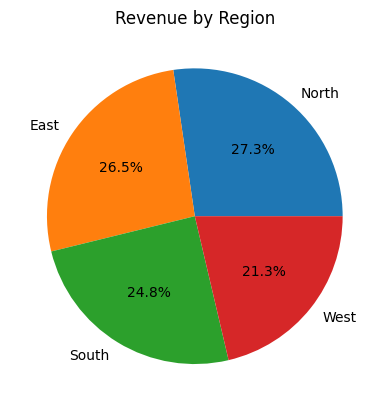

In [32]:
region_sales = (
    df.groupby("region")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)
region_sales.plot(kind="pie", autopct="%1.1f%%", title="Revenue by Region")
plt.ylabel("")
plt.show()

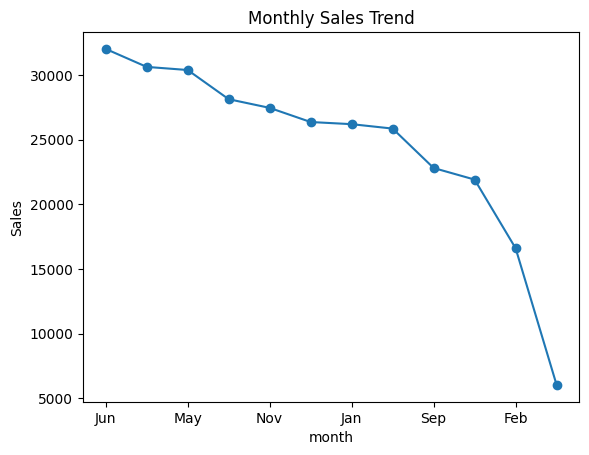

In [33]:
monthly_sales = (
    df.groupby("month")["sales_amount"]
      .sum()
      .sort_values(ascending = False)
)
monthly_sales.plot(marker="o", title="Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

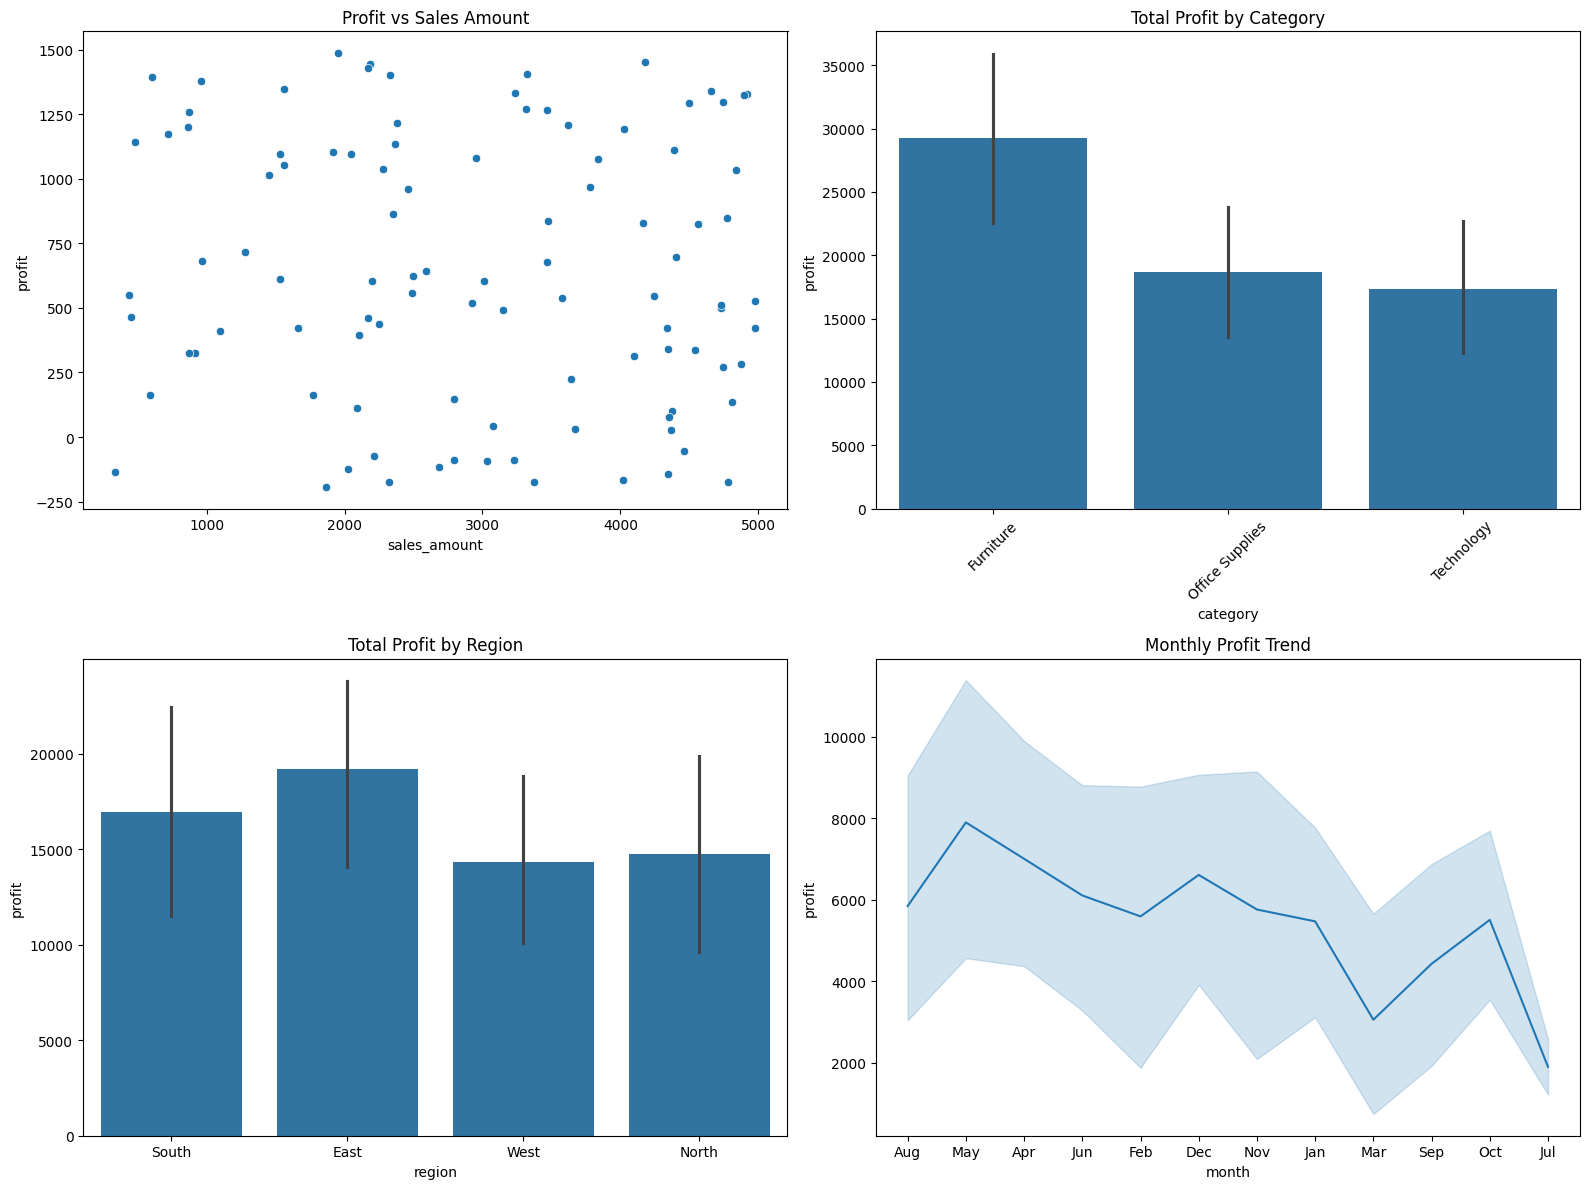

In [34]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x="sales_amount", y="profit", data=df)
plt.title("Profit vs Sales Amount")

plt.subplot(2, 2, 2)
sns.barplot(x="category", y="profit", data=df, estimator=sum)
plt.title("Total Profit by Category")
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.barplot(x="region", y="profit", data=df, estimator=sum)
plt.title("Total Profit by Region")

plt.subplot(2, 2, 4)
sns.lineplot(x="month", y="profit", data=df, estimator=sum)
plt.title("Monthly Profit Trend")

plt.tight_layout()
plt.show()

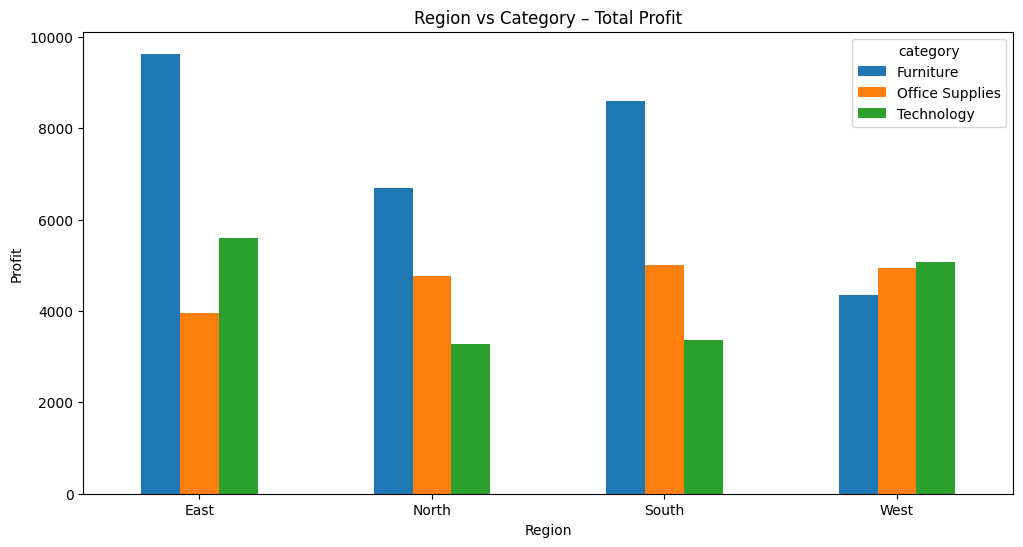

In [35]:
pivot_profit = pd.pivot_table(
    df,
    values="profit",
    index="region",
    columns="category",
    aggfunc="sum"
)

pivot_profit.plot(kind="bar", figsize=(12,6))
plt.title("Region vs Category – Total Profit")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.show()